In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup working!")
print(f"pandas version:{pd.__version__}")

Setup working!
pandas version:2.3.3


LOADING DATA


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("d:\Population of India.csv")


In [38]:
print(df.shape)      #rows and columns


(37, 12)


In [39]:
print(df.head(10))    #first 10 rows

  Sl No        State/UT  Population[50]  Percent (%)       Male    Female  \
0     1   Uttar Pradesh       199812341        16.50  104480510  95331831   
1     2     Maharashtra       112374333         9.28   58243056  54131277   
2     3           Bihar       104099452         8.60   54278157  49821295   
3     4     West Bengal        91276115         7.54   46809027  44467088   
4     5  Madhya Pradesh        72626809         6.00   37612306  35014503   
5     6      Tamil Nadu        72147030         5.96   36137975  36009055   
6     7       Rajasthan        68548437         5.66   35550997  32997440   
7     8       Karnataka        61095297         5.05   30966657  30128640   
8     9         Gujarat        60439692         4.99   31491260  28948432   
9    10  Andhra Pradesh        49386799         4.08   24738068  24648731   

  Difference between male and female  Sex ratio  Rural[51]  Urban[51]  \
0                            9148679        930  155111022   44470455   
1     

In [40]:
print(df.columns.tolist())   #column names

['Sl No', 'State/UT', 'Population[50]', 'Percent (%)', 'Male', 'Female', 'Difference between male and female', 'Sex ratio', 'Rural[51]', 'Urban[51]', 'Area[52] (km2)', 'Density (per km2)']


In [41]:
print(df.dtypes)   #data types of columns

Sl No                                  object
State/UT                               object
Population[50]                          int64
Percent (%)                           float64
Male                                    int64
Female                                  int64
Difference between male and female     object
Sex ratio                               int64
Rural[51]                               int64
Urban[51]                               int64
Area[52] (km2)                          int64
Density (per km2)                       int64
dtype: object


FILTERING 4 STATES


In [42]:
states = ['Uttar Pradesh','Bihar', 'Haryana','Punjab']     #filtering four states

df = df[df['State/UT'].isin(states)].reset_index(drop=True)
print(df)

  Sl No       State/UT  Population[50]  Percent (%)       Male    Female  \
0     1  Uttar Pradesh       199812341        16.50  104480510  95331831   
1     3          Bihar       104099452         8.60   54278157  49821295   
2    16         Punjab        27743338         2.29   14639465  13103873   
3    18        Haryana        25351462         2.09   13494734  11856728   

  Difference between male and female  Sex ratio  Rural[51]  Urban[51]  \
0                            9148679        930  155111022   44470455   
1                            4456862        918   92075028   11729609   
2                            1535592        895   17316800   10387436   
3                            1638006        879   16531493    8821588   

   Area[52] (km2)  Density (per km2)  
0          240928                828  
1           94163               1102  
2           50362                550  
3           44212                573  


CHECKING MISSING VALUES

In [43]:
print(df.isnull().sum())  
print(df.isnull().sum()/len(df)*100)


Sl No                                 0
State/UT                              0
Population[50]                        0
Percent (%)                           0
Male                                  0
Female                                0
Difference between male and female    0
Sex ratio                             0
Rural[51]                             0
Urban[51]                             0
Area[52] (km2)                        0
Density (per km2)                     0
dtype: int64
Sl No                                 0.0
State/UT                              0.0
Population[50]                        0.0
Percent (%)                           0.0
Male                                  0.0
Female                                0.0
Difference between male and female    0.0
Sex ratio                             0.0
Rural[51]                             0.0
Urban[51]                             0.0
Area[52] (km2)                        0.0
Density (per km2)                     0.0
dty

FIXING DATA TYPES

In [44]:
df['Population[50]'] = df['Population[50]'].astype(str).str.replace(',', '').astype(int)   #removing commas and converting to int

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'state':      ['Uttar Pradesh', 'Bihar', 'Haryana', 'Punjab',
                   'Uttar Pradesh', 'Bihar', 'Haryana', 'Punjab'],
    'year':       [2001, 2001, 2001, 2001,
                   2011, 2011, 2011, 2011],
    'total_pop':  [166.1, 82.9, 21.1, 24.4,
                   199.8, 104.1, 25.4, 27.7],
    'urban_pop':  [34.5, 8.7, 7.0, 8.2,
                   44.4, 11.7, 8.8, 10.4],
    'rural_pop':  [131.6, 74.2, 14.1, 16.2,
                   155.4, 92.4, 16.6, 17.3],
    'area_km2':   [240928, 94163, 44212, 50362,
                   240928, 94163, 44212, 50362],
}

df = pd.DataFrame(data)
print(df)

           state  year  total_pop  urban_pop  rural_pop  area_km2
0  Uttar Pradesh  2001      166.1       34.5      131.6    240928
1          Bihar  2001       82.9        8.7       74.2     94163
2        Haryana  2001       21.1        7.0       14.1     44212
3         Punjab  2001       24.4        8.2       16.2     50362
4  Uttar Pradesh  2011      199.8       44.4      155.4    240928
5          Bihar  2011      104.1       11.7       92.4     94163
6        Haryana  2011       25.4        8.8       16.6     44212
7         Punjab  2011       27.7       10.4       17.3     50362


Population Size Comparison

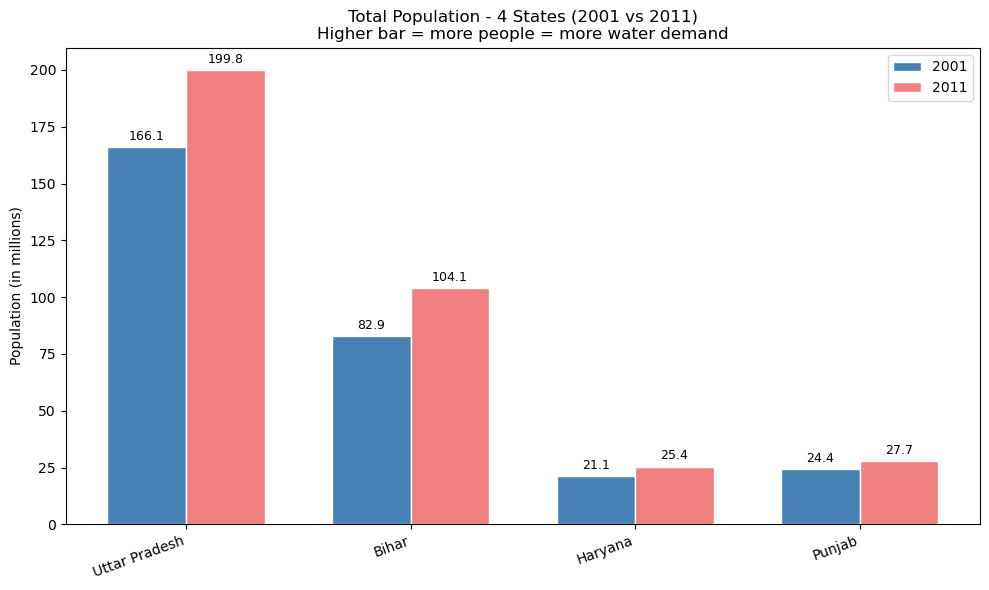

In [46]:
pop_2001= df[df['year']==2001]

pop_2011= df[df['year']==2011]

fig,ax = plt.subplots(figsize=(10,6))

states = ['Uttar Pradesh','Bihar','Haryana','Punjab']

x = np.arange(len(states))

width = 0.35

bars1 = ax.bar(x - width/2, pop_2001['total_pop'].values, width, label='2001',color='steelblue',edgecolor='white')
bars2 = ax.bar(x + width/2, pop_2011['total_pop'].values, width, label='2011',color='lightcoral',edgecolor='white')

#Add value labels on top of each bar so exact values can be seen

ax.bar_label(bars1,fmt='%.1f',padding=3,fontsize=9)
ax.bar_label(bars2,fmt='%.1f',padding=3,fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(states,rotation=20,ha='right')

#labels and title
ax.set_ylabel('Population (in millions)')
ax.set_title('Total Population - 4 States (2001 vs 2011)\nHigher bar = more people = more water demand')
ax.legend()

plt.tight_layout()
plt.show()

Urban Rural Split

Urban % by state (2011):
           state  urban_pct  rural_pct
0  Uttar Pradesh       22.2       77.8
1          Bihar       11.2       88.8
2        Haryana       34.6       65.4
3         Punjab       37.5       62.5


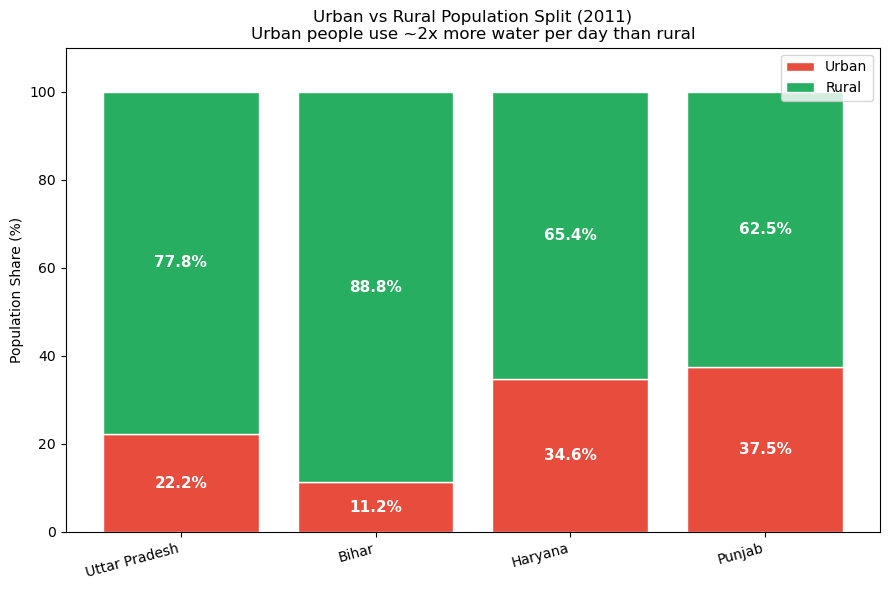

In [47]:

df_2011 = df[df['year'] == 2011].reset_index(drop=True)

# Calculate urban percentage for each state
# This creates a new column in df_2011
df_2011['urban_pct'] = (df_2011['urban_pop'] / df_2011['total_pop']) * 100

# Calculate rural percentage — just the remaining portion
df_2011['rural_pct'] = 100 - df_2011['urban_pct']

print("Urban % by state (2011):")
# .round(1) rounds to 1 decimal place
print(df_2011[['state', 'urban_pct', 'rural_pct']].round(1))

# --- Plot stacked bar ---
fig, ax = plt.subplots(figsize=(9, 6))

# x positions for 4 states
x = np.arange(len(df_2011))

# Bottom layer = urban bars (plotted first = at the bottom)
ax.bar(x,
       df_2011['urban_pct'],
       label='Urban',
       color='#E74C3C',   # red
       edgecolor='white')

# Top layer = rural bars
# bottom=df_2011['urban_pct'] tells matplotlib to START this bar
# from where the urban bar ended (stacking on top)
ax.bar(x,
       df_2011['rural_pct'],
       bottom=df_2011['urban_pct'],
       label='Rural',
       color='#27AE60',   
       edgecolor='white')

# Add % text labels in the middle of each bar section
for i in range(len(df_2011)):
    
    ax.text(i,
            df_2011['urban_pct'].iloc[i] / 2,
            f"{df_2011['urban_pct'].iloc[i]:.1f}%",
            ha='center', va='center',
            fontweight='bold', color='white', fontsize=11)

    
    ax.text(i,
            df_2011['urban_pct'].iloc[i] + df_2011['rural_pct'].iloc[i] / 2,
            f"{df_2011['rural_pct'].iloc[i]:.1f}%",
            ha='center', va='center',
            fontweight='bold', color='white', fontsize=11)

# Replace x numbers with state names
ax.set_xticks(x)
ax.set_xticklabels(df_2011['state'], rotation=15, ha='right')

ax.set_ylabel('Population Share (%)')
ax.set_title('Urban vs Rural Population Split (2011)\nUrban people use ~2x more water per day than rural')
ax.legend(loc='upper right')
ax.set_ylim(0, 110)  

plt.tight_layout()
plt.show()

Population Density

Population Density (people per km²):
           state  year  density
0  Uttar Pradesh  2001    689.4
1          Bihar  2001    880.4
2        Haryana  2001    477.2
3         Punjab  2001    484.5
4  Uttar Pradesh  2011    829.3
5          Bihar  2011   1105.5
6        Haryana  2011    574.5
7         Punjab  2011    550.0


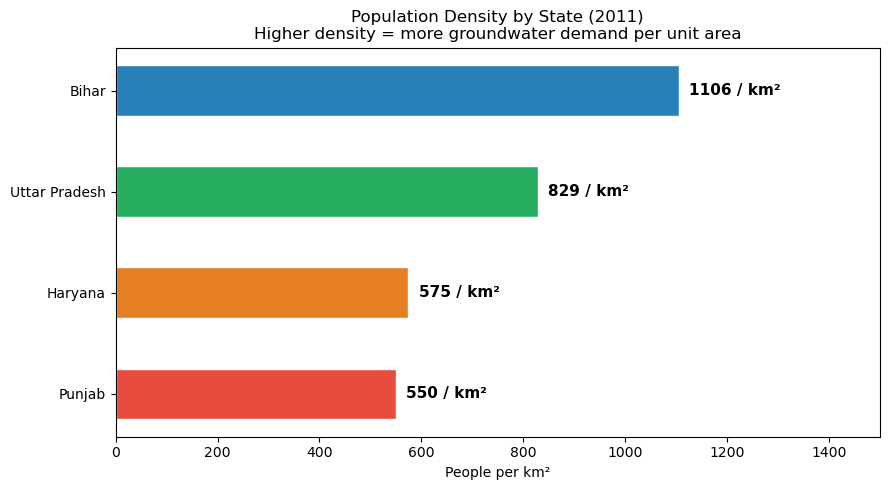

In [48]:
df['density'] = df['total_pop'] * 1e6 / df['area_km2']
# * 1e6 because total_pop is in millions — convert to actual people first

print("Population Density (people per km²):")
print(df[['state', 'year', 'density']].round(1))

# Use only 2011 data, sorted from highest to lowest density
df_density = (df[df['year'] == 2011]
              .sort_values('density', ascending=True))
# ascending=True because horizontal bars go left to right
# lowest on bottom, highest on top — easier to read

fig, ax = plt.subplots(figsize=(9, 5))


bars = ax.barh(df_density['state'], #barh instead of bar for horizontal bars
               df_density['density'],
               color=['#E74C3C', '#E67E22', '#27AE60', '#2980B9'],
               edgecolor='white',
               height=0.5)


for bar, val in zip(bars, df_density['density']):
    ax.text(bar.get_width() + 20,    # slightly right of bar end
            bar.get_y() + bar.get_height() / 2,  # vertically centered
            f'{val:.0f} / km²',
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('People per km²')
ax.set_title('Population Density by State (2011)\nHigher density = more groundwater demand per unit area')
ax.set_xlim(0,1500)

plt.tight_layout()
plt.show()

Calculating Growth Rate(CAGR)

In [49]:
cagr={}

for state in states:
    pop_2001 = df[(df['state'] == state) & (df['year'] == 2001)]['total_pop'].values[0]
    pop_2011 = df[(df['state'] == state) & (df['year'] == 2011)]['total_pop'].values[0]

    rate = ((pop_2011 / pop_2001) ** (1/10) - 1) * 100 

    cagr[state] = rate
    print(f"{state:20s}: {rate:.2f}% per year")

    print()
    print("Higher % = faster growth = more water demand in future")

Uttar Pradesh       : 1.86% per year

Higher % = faster growth = more water demand in future
Bihar               : 2.30% per year

Higher % = faster growth = more water demand in future
Haryana             : 1.87% per year

Higher % = faster growth = more water demand in future
Punjab              : 1.28% per year

Higher % = faster growth = more water demand in future


Annual Population

In [51]:
rows = []  

for state in states:
    # Get base values
    pop_01 = df[(df['state'] == state) & (df['year'] == 2001)]['total_pop'].values[0]
    pop_11 = df[(df['state'] == state) & (df['year'] == 2011)]['total_pop'].values[0]

    for year in range(2005, 2025):  # 2005 to 2024 inclusive

        if year <= 2011:
            # Between 2001 and 2011 — use full CAGR
            # (year - 2001) = how many years from our base year 2001
            pop = pop_01 * ((1 + cagr[state]) ** (year - 2001))

        else:
            # After 2011 — growth slows down slightly
            # 0.85 = 85% of old rate (standard demographic slowdown assumption)
            # (year - 2011) = how many years past 2011
            pop = pop_11 * ((1 + cagr[state] * 0.85) ** (year - 2011))

        # Store this row as a dictionary
        rows.append({
            'state': state,
            'year':  year,
            'population_millions': round(pop, 3)
        })

# Convert list of dicts to DataFrame
df_annual = pd.DataFrame(rows)

print(f"Shape: {df_annual.shape}")  # 80 rows (4 states × 20 years)
print(df_annual.head(10))

Shape: (80, 3)
           state  year  population_millions
0  Uttar Pradesh  2005            11182.172
1  Uttar Pradesh  2006            32030.616
2  Uttar Pradesh  2007            91749.650
3  Uttar Pradesh  2008           262811.004
4  Uttar Pradesh  2009           752805.315
5  Uttar Pradesh  2010          2156362.681
6  Uttar Pradesh  2011          6176762.994
7  Uttar Pradesh  2012              516.437
8  Uttar Pradesh  2013             1334.872
9  Uttar Pradesh  2014             3450.337


Population Growth Chart

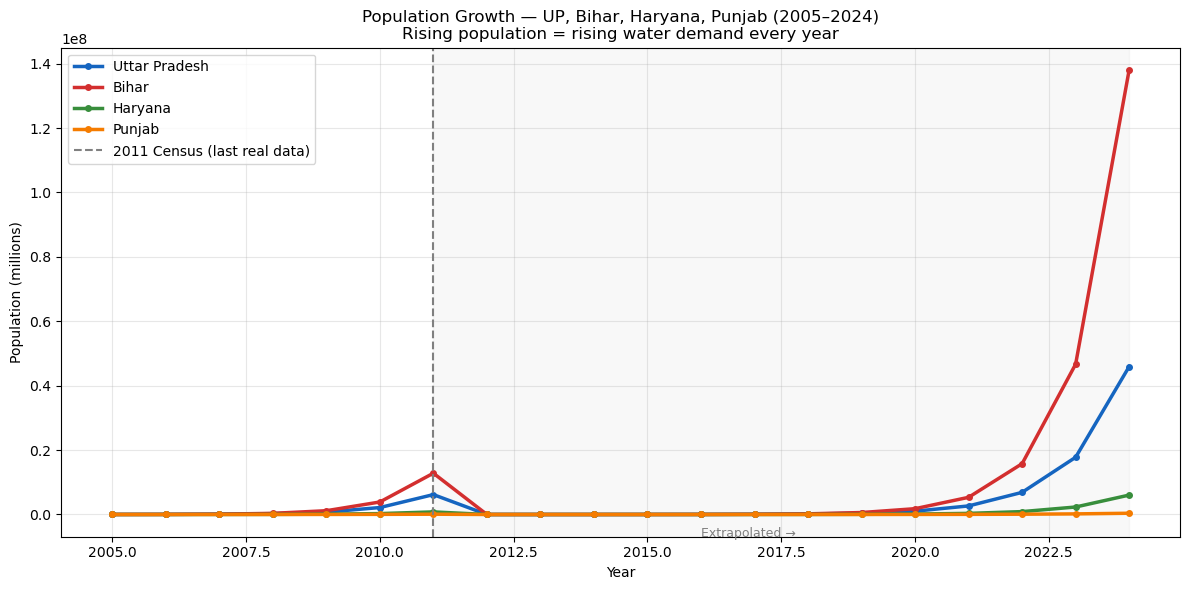

In [61]:
state_colors = {
    'Uttar Pradesh': '#1565C0',  # dark blue
    'Bihar':         '#D32F2F',  # dark red
    'Haryana':       '#388E3C',  # dark green
    'Punjab':        '#F57C00',  # orange
}

fig, ax = plt.subplots(figsize=(12, 6))

for state in states:
    # Filter to just this state's rows
    d = df_annual[df_annual['state'] == state]

    # Plot line — one line per state
    ax.plot(d['year'],                    # x axis = years
            d['population_millions'],     # y axis = population
            color=state_colors[state],    # each state gets its own colour
            linewidth=2.5,
            marker='o',                   # small dot at each data point
            markersize=4,
            label=state)


ax.axvline(2011,
           color='gray',
           linestyle='--',
           linewidth=1.5,
           label='2011 Census (last real data)')

# Shade the estimated area (post-2011) slightly to show it's extrapolated
ax.axvspan(2011, 2024, alpha=0.05, color='gray')
ax.text(2016, ax.get_ylim()[0] + 5,
        'Extrapolated →',
        color='gray', fontsize=9)

ax.set_xlabel('Year')
ax.set_ylabel('Population (millions)')
ax.set_title('Population Growth — UP, Bihar, Haryana, Punjab (2005–2024)\n'
             'Rising population = rising water demand every year')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Urbanisation Trend

            state  year  population_millions  urban_frac  urban_pct  \
0   Uttar Pradesh  2005         1.118217e+04       0.180       18.0   
5   Uttar Pradesh  2010         2.156363e+06       0.215       21.5   
10  Uttar Pradesh  2015         8.918330e+03       0.250       25.0   
15  Uttar Pradesh  2020         1.028948e+06       0.285       28.5   
19  Uttar Pradesh  2024         4.592843e+07       0.313       31.3   
20          Bihar  2005         9.870604e+03       0.083        8.3   
25          Bihar  2010         3.882221e+06       0.108       10.8   
30          Bihar  2015         7.967575e+03       0.133       13.3   
35          Bihar  2020         1.803726e+06       0.158       15.8   
39          Bihar  2024         1.380530e+08       0.178       17.8   
40        Haryana  2005         1.435694e+03       0.300       30.0   
45        Haryana  2010         2.805667e+05       0.340       34.0   
50        Haryana  2015         1.145188e+03       0.380       38.0   
55    

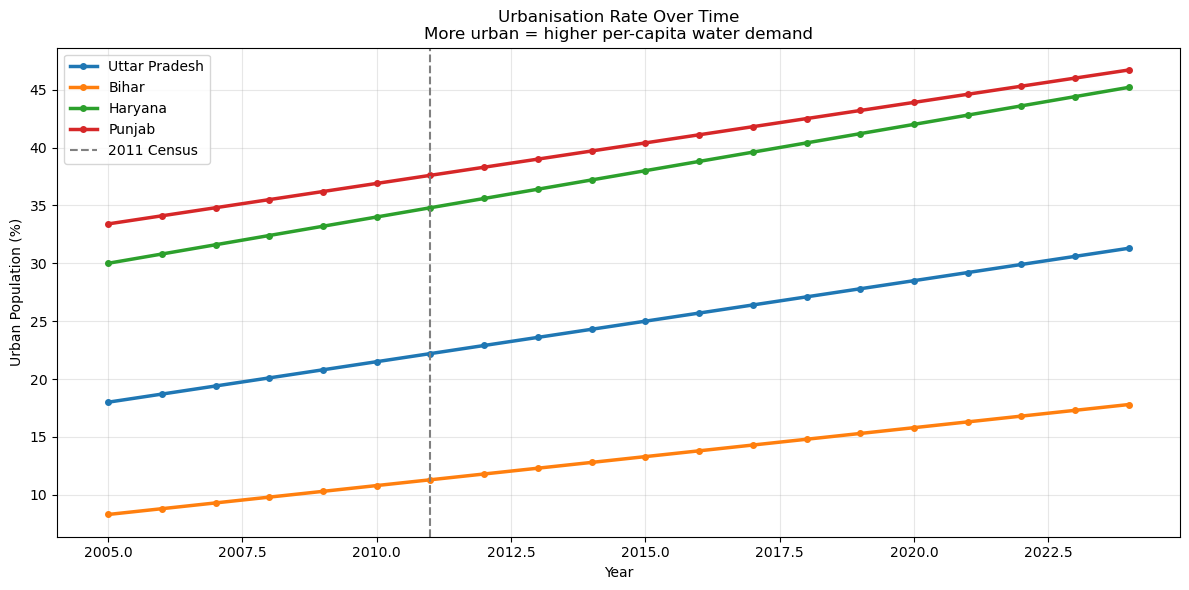

In [62]:
urban_frac_2011 = {
    'Uttar Pradesh': 0.222,   # 22.2% urban in 2011
    'Bihar':         0.113,   # 11.3% — most rural state
    'Haryana':       0.348,   # 34.8%
    'Punjab':        0.376    # 37.6% — most urban state
}

# Urban growth rate per year (fraction)
# Cities grow ~0.6-0.8% more urban every year in these states
urban_growth = {
    'Uttar Pradesh': 0.007,
    'Bihar':         0.005,   # slowest urbanising
    'Haryana':       0.008,
    'Punjab':        0.007
}

# Add urban fraction to df_annual
def get_urban_frac(row):
    state = row['state']
    year  = row['year']

    if year <= 2011:
        # Before 2011: work backwards from 2011 value
        years_before = 2011 - year
        frac = urban_frac_2011[state] - (urban_growth[state] * years_before)
    else:
        # After 2011: add growth each year
        years_after = year - 2011
        frac = urban_frac_2011[state] + (urban_growth[state] * years_after)

    return min(frac, 0.95)


df_annual['urban_frac'] = df_annual.apply(get_urban_frac, axis=1)

# Convert to percentage for readability
df_annual['urban_pct'] = df_annual['urban_frac'] * 100

print(df_annual[df_annual['year'].isin([2005, 2010, 2015, 2020, 2024])])

fig, ax = plt.subplots(figsize=(12, 6))

for state in states:
    d = df_annual[df_annual['state'] == state]
    ax.plot(d['year'], d['urban_pct'],
            
            linewidth=2.5, marker='o',
            markersize=4, label=state)

ax.axvline(2011, color='gray', linestyle='--', linewidth=1.5,
           label='2011 Census')

ax.set_xlabel('Year')
ax.set_ylabel('Urban Population (%)')
ax.set_title('Urbanisation Rate Over Time\n'
             'More urban = higher per-capita water demand')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Feature 1 : Water Demand

Water demand (MLD) sample:
            state  water_demand_MLD
19  Uttar Pradesh      4.149404e+09
39          Bihar      1.126098e+10
59        Haryana      5.994768e+08
79         Punjab      3.914098e+07


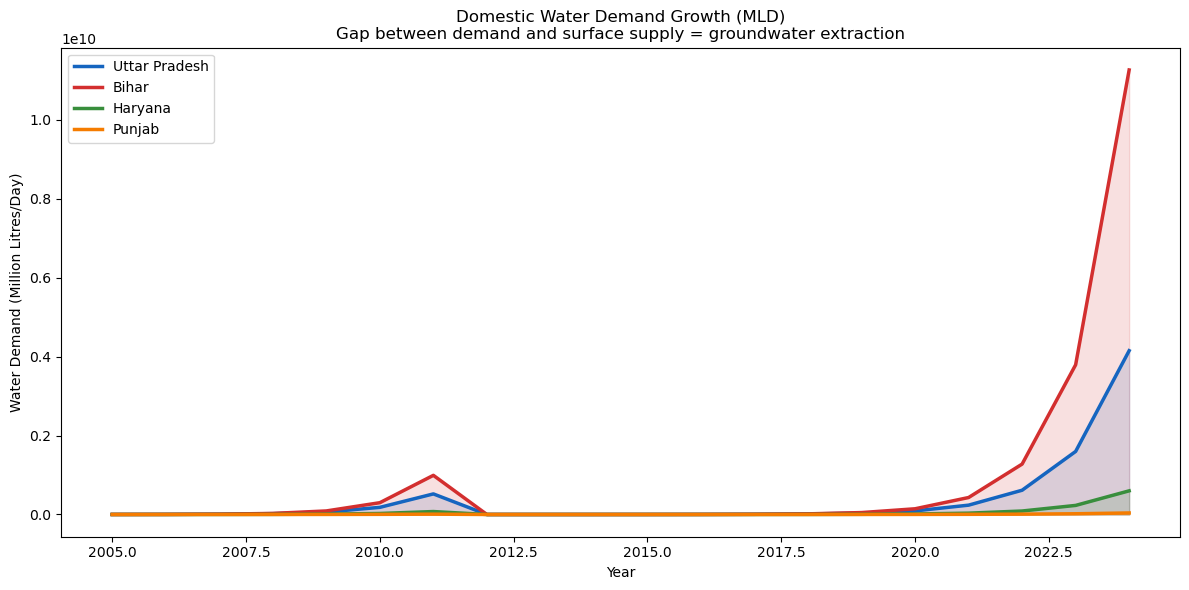

In [64]:
URBAN_LPCD = 135   # litres per capita per day
RURAL_LPCD = 70

# Urban population in millions
df_annual['urban_pop_M'] = df_annual['population_millions'] * df_annual['urban_frac']

# Rural population in millions
df_annual['rural_pop_M'] = df_annual['population_millions'] * (1 - df_annual['urban_frac'])

# Water demand in Million Litres per Day (MLD)

df_annual['water_demand_MLD'] = (
    (df_annual['urban_pop_M'] * 1e6 * URBAN_LPCD) +
    (df_annual['rural_pop_M'] * 1e6 * RURAL_LPCD)
) / 1e6

print("Water demand (MLD) sample:")
print(df_annual[df_annual['year'] == 2024][['state', 'water_demand_MLD']].round(1))

# Plot water demand growth
fig, ax = plt.subplots(figsize=(12, 6))
for state in states:
    d = df_annual[df_annual['state'] == state]
    ax.fill_between(d['year'], 0, d['water_demand_MLD'],
                    alpha=0.15,color=state_colors[state])
    ax.plot(d['year'], d['water_demand_MLD'],
            color=state_colors[state], linewidth=2.5, label=state)

ax.set_xlabel('Year')
ax.set_ylabel('Water Demand (Million Litres/Day)')
ax.set_title('Domestic Water Demand Growth (MLD)\n'
             'Gap between demand and surface supply = groundwater extraction')
ax.legend()
plt.tight_layout()
plt.show()

Feature 2: Density

In [65]:
area_km2 = {
    'Uttar Pradesh': 240928,
    'Bihar':         94163,
    'Haryana':       43297,
    'Punjab':        50362
}

df_annual['area_km2'] = df_annual['state'].map(area_km2)

df_annual['pop_density'] = df_annual['state'].map(area_km2)
df_annual['area_km2']

print(df_annual[df_annual['year'] == 2024][['state', 'pop_density']].round(1))

            state  pop_density
19  Uttar Pradesh       240928
39          Bihar        94163
59        Haryana        43297
79         Punjab        50362


Feature 3: Yearwise Growth Rate

In [66]:
df_annual= df_annual.sort_values(['state', 'year']).reset_index(drop=True)

df_annual['pop_growth_pct'] = (
    df_annual.groupby('state')['population_millions']
    .pct_change() * 100)

print(df_annual[df_annual['year'].isin([2006,2011,2015,2020])]
      [['state','year','pop_growth_pct']].round(3))

            state  year  pop_growth_pct
1           Bihar  2006         230.329
6           Bihar  2011         230.329
10          Bihar  2015         195.780
15          Bihar  2020         195.780
21        Haryana  2006         187.207
26        Haryana  2011         187.207
30        Haryana  2015         159.126
35        Haryana  2020         159.126
41         Punjab  2006         127.657
46         Punjab  2011         127.657
50         Punjab  2015         108.509
55         Punjab  2020         108.509
61  Uttar Pradesh  2006         186.444
66  Uttar Pradesh  2011         186.444
70  Uttar Pradesh  2015         158.477
75  Uttar Pradesh  2020         158.477


Population Index

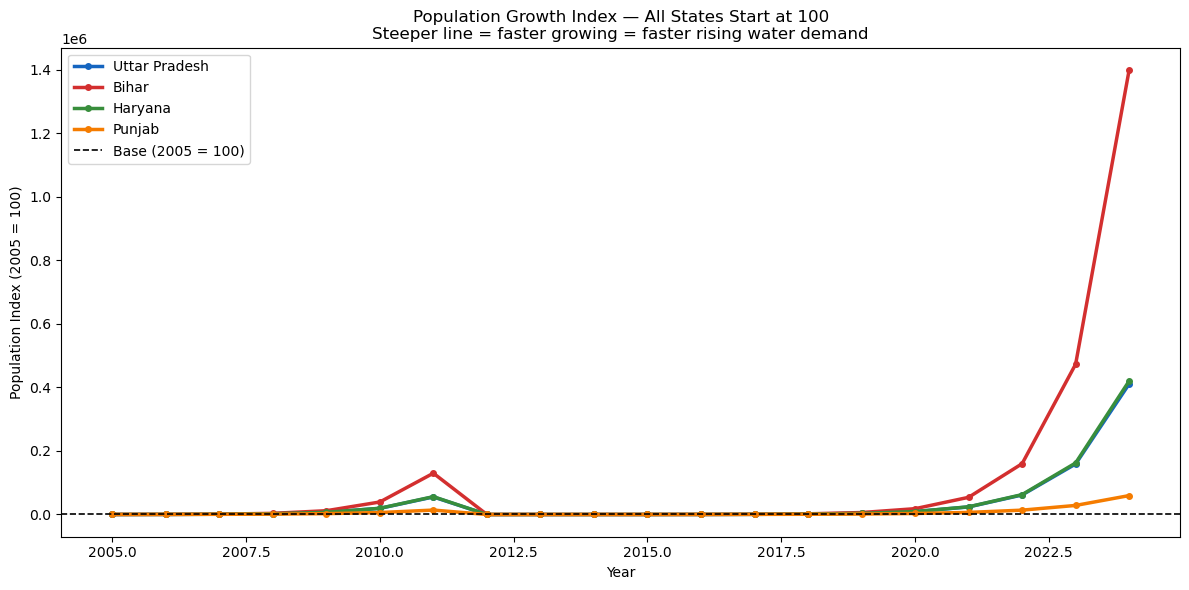

In [67]:
pop_base_2005 = (df_annual[df_annual['year'] == 2005]
                 .set_index('state')['population_millions'])


df_annual['pop_index'] = df_annual.apply(
    lambda row: (row['population_millions'] / pop_base_2005[row['state']]) * 100,
    axis=1   # axis=1 = row by row
)

# --- Plot index ---
fig, ax = plt.subplots(figsize=(12, 6))

for state in states:
    d = df_annual[df_annual['state'] == state]
    ax.plot(d['year'], d['pop_index'],
            color=state_colors[state], linewidth=2.5,
            marker='o', markersize=4, label=state)

ax.axhline(100, color='black', linewidth=1.2, linestyle='--',
           label='Base (2005 = 100)')

ax.set_xlabel('Year')
ax.set_ylabel('Population Index (2005 = 100)')
ax.set_title('Population Growth Index — All States Start at 100\n'
             'Steeper line = faster growing = faster rising water demand')
ax.legend()
plt.tight_layout()
plt.show()

In [68]:
final_cols = [
    'state', 'year',
    'population_millions',   # raw population
    'pop_density',           # people per km²
    'urban_frac',            # fraction urban
    'urban_pct',             # % urban
    'urban_pop_M',           # urban population in millions
    'rural_pop_M',           # rural population in millions
    'water_demand_MLD',      # key feature for ML
    'pop_growth_pct',        # year on year growth rate
    'pop_index',             # index from 2005 base
]

df_export = df_annual[final_cols]

df_export.to_csv('population_features.csv', index=False)

print(f" Saved: population_features.csv")
print(f"   Shape: {df_export.shape}")
print(f"\nPreview:")
print(df_export[df_export['year'] == 2024].round(3))

 Saved: population_features.csv
   Shape: (80, 11)

Preview:
            state  year  population_millions  pop_density  urban_frac  \
19          Bihar  2024         1.380530e+08        94163       0.178   
39        Haryana  2024         6.032168e+06        43297       0.452   
59         Punjab  2024         3.900252e+05        50362       0.467   
79  Uttar Pradesh  2024         4.592843e+07       240928       0.313   

    urban_pct   urban_pop_M   rural_pop_M  water_demand_MLD  pop_growth_pct  \
19       17.8  2.457344e+07  1.134796e+08      1.126098e+10         195.780   
39       45.2  2.726540e+06  3.305628e+06      5.994768e+08         159.126   
59       46.7  1.821418e+05  2.078834e+05      3.914098e+07         108.509   
79       31.3  1.437560e+07  3.155283e+07      4.149404e+09         158.477   

      pop_index  
19  1398627.876  
39   420156.937  
59    59508.217  
79   410729.099  


In [69]:
df_export.to_csv('population_features.csv', index=False)
print("Saved!")

Saved!
